# Knee Osteoarthritis Severity Classification – Improved Pipeline (v2)

**Task**: Multi-class ordinal classification of knee X-ray images into KL grades 0–4.

| Grade | Label | Description |
|-------|-------|-------------|
| 0 | Healthy | No signs of osteoarthritis |
| 1 | Doubtful | Doubtful joint narrowing, possible osteophytic lipping |
| 2 | Minimal | Definite osteophytes, possible joint space narrowing |
| 3 | Moderate | Multiple osteophytes, definite joint space narrowing, mild sclerosis |
| 4 | Severe | Large osteophytes, significant joint narrowing, severe sclerosis |

## What changed vs. v1 (and why)

The v1 run finished at **65.46% test accuracy** with **Grade 1 F1 = 0.27** and a verdict of *underfitting* (train acc < val acc). This v2 targets each issue specifically:

| # | Change | Why |
|---|--------|-----|
| 1 | **Ordinal Gaussian-smoothed soft labels** (replaces vanilla label smoothing) | KL grades are ordinal — confusing G0↔G4 must cost more than G2↔G3. Biggest expected lift, especially for Grade 1. |
| 2 | **Quadratic Weighted Kappa (QWK)** as early-stopping & checkpoint metric | Accuracy is the wrong signal for ordinal classification; QWK is the clinical standard. |
| 3 | **WeightedRandomSampler** for training | Class weights in the loss alone don't guarantee Grade 4 appears in every batch — sampler does. |
| 4 | **CLAHE preprocessing** | Contrast-limited histogram equalization sharpens joint-space and osteophyte visibility on X-rays. |
| 5 | **Lighter augmentation** | v1 was underfitting; auto-contrast + sharpness + heavy color jitter were suppressing the train signal. |
| 6 | **Discriminative learning rates** | Backbone early layers at LR/100, late stages at LR/10, head at LR. |
| 7 | **AdamW + cosine schedule with linear warmup** | Cleaner replacement for the v1 schedule. |
| 8 | **Test-Time Augmentation actually used in final eval** | Defined-but-unused in v1; here it's the headline number. |
| 9 | **Optional smaller backbone path (B0 @ 224px)** for CPU users | B4@380 on CPU is impractical. |

> ⚠️ **Environment note**: v1 ran on CPU. EfficientNet-B4 at 380px is ~30 min/epoch on CPU. If you have any GPU access (Colab/Kaggle free tier work), use it. The flag `USE_SMALL_BACKBONE` below switches to B0@224 for tractable CPU iteration.

## 1. Imports & Reproducibility

In [2]:
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
from torchvision import datasets, models, transforms
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    cohen_kappa_score,
)
from PIL import Image

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('⚠️  Running on CPU. Consider USE_SMALL_BACKBONE=True below for tractable iteration.')

Using device: cuda
GPU: Tesla T4


In [3]:
from pathlib import Path

DATA_DIR  = Path('/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity')
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = DATA_DIR / 'val'
TEST_DIR  = DATA_DIR / 'test'

MODEL_DIR = Path('/kaggle/working/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f'TRAIN_DIR: {TRAIN_DIR}  (exists: {TRAIN_DIR.exists()})')
print(f'VAL_DIR  : {VAL_DIR}  (exists: {VAL_DIR.exists()})')
print(f'TEST_DIR : {TEST_DIR}  (exists: {TEST_DIR.exists()})')

# --- Backbone selection ---
USE_SMALL_BACKBONE = (DEVICE.type == 'cpu')

if USE_SMALL_BACKBONE:
    BACKBONE   = 'efficientnet_b0'
    IMG_SIZE   = 224
    BATCH_SIZE = 32
else:
    BACKBONE   = 'efficientnet_b4'
    IMG_SIZE   = 380
    BATCH_SIZE = 16

NUM_CLASSES   = 5
NUM_EPOCHS    = 50
HEAD_LR       = 3e-4
BACKBONE_LR   = 3e-5
WEIGHT_DECAY  = 1e-4
PATIENCE      = 10
WARMUP_EPOCHS = 3
PHASE1_EPOCHS = 2
GAUSSIAN_SIGMA = 0.65

CLASS_NAMES  = ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
GRADE_LABELS = {0: 'Healthy', 1: 'Doubtful', 2: 'Minimal', 3: 'Moderate', 4: 'Severe'}

print(f'\nBackbone   : {BACKBONE}')
print(f'Image size : {IMG_SIZE}')
print(f'Batch size : {BATCH_SIZE}')

TRAIN_DIR: /kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/train  (exists: True)
VAL_DIR  : /kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/val  (exists: True)
TEST_DIR : /kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/test  (exists: True)

Backbone   : efficientnet_b4
Image size : 380
Batch size : 16


## 2. Configuration

In [4]:
# --- Auto-detect dataset location (Kaggle / Colab / local) ---
# This dataset is published with several layouts depending on where it's mounted.
# We walk the candidate roots and pick the first one that contains all 5 class folders (0..4).
import os
from pathlib import Path

def _has_class_folders(p: Path) -> bool:
    return p.is_dir() and all((p / str(c)).is_dir() for c in range(5))

def _find_split_root(split_name: str) -> Path:
    """Return the directory that contains 0/, 1/, 2/, 3/, 4/ subfolders for the given split."""
    candidates = [
        # Kaggle — common layouts for shashwatwork/knee-osteoarthritis-dataset-with-severity
        Path('/kaggle/input/knee-osteoarthritis-dataset-with-severity') / split_name,
        Path('/kaggle/input/knee-osteoarthritis-dataset-with-severity/KneeXrayData/ClsKLData/kneeKL224') / split_name,
        Path('/kaggle/input/knee-osteoarthritis-dataset-with-severity/ClsKLData/kneeKL224') / split_name,
        Path('/kaggle/input/knee-osteoarthritis-dataset-with-severity/kneeKL224') / split_name,
        # Local / original layout from earlier notebook
        Path('data') / split_name,
        Path('dataset') / split_name,
    ]
    for c in candidates:
        if _has_class_folders(c):
            return c

    # Fallback: walk /kaggle/input recursively for any directory whose name matches the split
    # and which contains class-folders 0..4 underneath.
    for root in [Path('/kaggle/input'), Path('.')]:
        if not root.exists():
            continue
        for dirpath, dirnames, _ in os.walk(root):
            if Path(dirpath).name == split_name and _has_class_folders(Path(dirpath)):
                return Path(dirpath)
    raise FileNotFoundError(
        f"Couldn't auto-locate the '{split_name}' split. Checked: {[str(c) for c in candidates]}"
    )

TRAIN_DIR = _find_split_root('train')
# Some versions of the dataset call validation 'val', others 'valid'
try:
    VAL_DIR = _find_split_root('val')
except FileNotFoundError:
    VAL_DIR = _find_split_root('valid')
TEST_DIR = _find_split_root('test')
DATA_DIR = TRAIN_DIR.parent

# Models go to a writable location (Kaggle's /kaggle/working or local ./models)
if Path('/kaggle/working').exists():
    MODEL_DIR = Path('/kaggle/working/models')
else:
    MODEL_DIR = Path('models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f'TRAIN_DIR: {TRAIN_DIR}')
print(f'VAL_DIR  : {VAL_DIR}')
print(f'TEST_DIR : {TEST_DIR}')
print(f'MODEL_DIR: {MODEL_DIR}')

# --- Backbone selection ---
USE_SMALL_BACKBONE = (DEVICE.type == 'cpu')   # auto-pick B0 on CPU; flip to False on GPU

if USE_SMALL_BACKBONE:
    BACKBONE   = 'efficientnet_b0'
    IMG_SIZE   = 224
    BATCH_SIZE = 32
else:
    BACKBONE   = 'efficientnet_b4'
    IMG_SIZE   = 380
    BATCH_SIZE = 16

# --- Hyperparameters ---
NUM_CLASSES   = 5
NUM_EPOCHS    = 50
HEAD_LR       = 3e-4
BACKBONE_LR   = 3e-5
WEIGHT_DECAY  = 1e-4
PATIENCE      = 10
WARMUP_EPOCHS = 3
PHASE1_EPOCHS = 2
GAUSSIAN_SIGMA = 0.65
MIXUP_ALPHA   = 0.0

CLASS_NAMES  = ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
GRADE_LABELS = {0: 'Healthy', 1: 'Doubtful', 2: 'Minimal', 3: 'Moderate', 4: 'Severe'}

print(f'\nBackbone   : {BACKBONE}')
print(f'Image size : {IMG_SIZE}')
print(f'Batch size : {BATCH_SIZE}')

TRAIN_DIR: /kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/train
VAL_DIR  : /kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/val
TEST_DIR : /kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/test
MODEL_DIR: /kaggle/working/models

Backbone   : efficientnet_b4
Image size : 380
Batch size : 16


## 3. Data Inventory

In [5]:
splits = {'train': TRAIN_DIR, 'val': VAL_DIR, 'test': TEST_DIR}
counts = {}
# Some Kaggle versions store .png, others .jpg — count any image
IMAGE_EXTS = ('.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG')
for split, path in splits.items():
    counts[split] = [
        sum(1 for p in (path / str(g)).iterdir() if p.suffix in IMAGE_EXTS)
        for g in range(NUM_CLASSES)
    ]

print(f"{'Grade':<8} {'Train':>8} {'Val':>8} {'Test':>8}")
print('-' * 36)
for g in range(NUM_CLASSES):
    label = GRADE_LABELS[g]
    print(f"{g} ({label:<8}) {counts['train'][g]:>8} {counts['val'][g]:>8} {counts['test'][g]:>8}")
print('-' * 36)
print(f"{'Total':<8} {sum(counts['train']):>8} {sum(counts['val']):>8} {sum(counts['test']):>8}")

Grade       Train      Val     Test
------------------------------------
0 (Healthy )     2286      328      639
1 (Doubtful)     1046      153      296
2 (Minimal )     1516      212      447
3 (Moderate)      757      106      223
4 (Severe  )      173       27       51
------------------------------------
Total        5778      826     1656


## 4. CLAHE Preprocessing + Augmentation

**CLAHE** (Contrast-Limited Adaptive Histogram Equalization) is the standard preprocessing trick for chest/skeletal X-rays — it equalizes contrast in local tiles, which highlights joint-space narrowing and osteophytes that are otherwise washed out by uniform brightness.

**Augmentation (lighter than v1)**:
- ✅ Horizontal flip (knees are bilateral → safe)
- ✅ Small rotation (±8°)
- ✅ Small affine translate/scale
- ❌ Removed: aggressive ColorJitter, RandomAutocontrast, RandomAdjustSharpness — these were suppressing the train signal in v1.

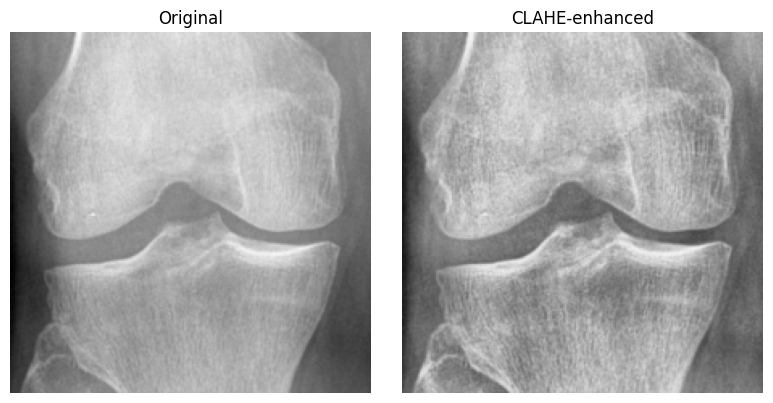

In [6]:
import cv2

class CLAHETransform:
    """Apply CLAHE to a PIL grayscale-equivalent image, return a 3-channel PIL image."""
    def __init__(self, clip_limit=2.0, tile_grid=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)

    def __call__(self, pil_img: Image.Image) -> Image.Image:
        arr = np.array(pil_img.convert('L'))
        enhanced = self.clahe.apply(arr)
        rgb = np.stack([enhanced, enhanced, enhanced], axis=-1)
        return Image.fromarray(rgb)

clahe = CLAHETransform()

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    clahe,
    transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.RandomAffine(degrees=0, translate=(0.04, 0.04), scale=(0.96, 1.04)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

eval_transforms = transforms.Compose([
    clahe,
    transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

# Quick visual sanity check on CLAHE
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
def _first_image_in(folder: Path) -> Path:
    for p in folder.iterdir():
        if p.suffix.lower() in {'.png', '.jpg', '.jpeg'}:
            return p
    raise FileNotFoundError(f'No images found in {folder}')

sample_path = _first_image_in(TRAIN_DIR / '2')
orig = Image.open(sample_path).convert('L')
enh  = clahe(orig)
axes[0].imshow(orig, cmap='gray'); axes[0].set_title('Original');         axes[0].axis('off')
axes[1].imshow(enh);               axes[1].set_title('CLAHE-enhanced');   axes[1].axis('off')
plt.tight_layout(); plt.show()

## 5. Datasets, Weighted Sampler, DataLoaders

In [7]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=eval_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=eval_transforms)

# WeightedRandomSampler — every batch becomes class-balanced regardless of dataset imbalance.
# This is stronger than class-weighted loss alone, because Grade 4 (only 173 imgs) is otherwise
# absent from most batches when batch_size=16 — gradient signal for it stays noisy.
train_targets = np.array([y for _, y in train_dataset.samples])
class_sample_count = np.bincount(train_targets, minlength=NUM_CLASSES)
sample_weights = 1.0 / class_sample_count[train_targets]
sampler = WeightedRandomSampler(
    weights=torch.as_tensor(sample_weights, dtype=torch.double),
    num_samples=len(train_targets),
    replacement=True,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Class-to-index mapping: {train_dataset.class_to_idx}')
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')
print(f'Per-class sampling probability (~1/N for each class): each batch will be ~class-balanced.')

Class-to-index mapping: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}
Train: 5778 | Val: 826 | Test: 1656
Per-class sampling probability (~1/N for each class): each batch will be ~class-balanced.


## 6. Ordinal Soft-Label Loss

Vanilla cross-entropy treats Grade 0→4 as equally wrong as Grade 0→1 — clinically nonsense. Ordinal **Gaussian-smoothed soft labels** spread the target probability over neighbouring grades:

```
true grade 2  →  [0.05, 0.24, 0.42, 0.24, 0.05]   (σ=0.65)
true grade 0  →  [0.61, 0.32, 0.06, 0.01, 0.00]   (σ=0.65)
```

Combined with **KL-divergence loss**, this directly optimizes for QWK rather than accuracy.

In [8]:
def gaussian_soft_labels(targets: torch.Tensor, num_classes: int, sigma: float = 0.65) -> torch.Tensor:
    """Convert hard labels to Gaussian-smoothed ordinal soft labels."""
    grades = torch.arange(num_classes, dtype=torch.float32, device=targets.device)
    # (B, K): squared distance from target grade
    dist_sq = (grades.unsqueeze(0) - targets.unsqueeze(1).float()) ** 2
    soft = torch.exp(-dist_sq / (2 * sigma ** 2))
    soft = soft / soft.sum(dim=1, keepdim=True)
    return soft


class OrdinalSoftCrossEntropy(nn.Module):
    """KL-divergence between Gaussian-smoothed soft labels and predicted log-softmax.

    Optionally weighted per (true) class to keep the imbalance signal.
    """
    def __init__(self, num_classes: int, sigma: float = 0.65,
                 class_weights: torch.Tensor | None = None):
        super().__init__()
        self.num_classes = num_classes
        self.sigma = sigma
        self.class_weights = class_weights

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        soft = gaussian_soft_labels(targets, self.num_classes, self.sigma)
        log_probs = F.log_softmax(logits, dim=1)
        per_sample = -(soft * log_probs).sum(dim=1)        # KL up to constant
        if self.class_weights is not None:
            w = self.class_weights[targets]
            per_sample = per_sample * w
            return per_sample.sum() / w.sum()
        return per_sample.mean()


# Mild class weights — sampler does most of the imbalance work, weights handle residual asymmetry.
train_counts = np.array(counts['train'], dtype=float)
raw_weights  = train_counts.sum() / (NUM_CLASSES * train_counts)
# Soften so the sampler+weights combo isn't double-penalising rare classes
class_weights = torch.tensor(np.sqrt(raw_weights).astype(np.float32)).to(DEVICE)
print('Softened class weights (sqrt of inverse-frequency):')
for g, w in enumerate(class_weights.cpu().numpy()):
    print(f'  Grade {g} ({GRADE_LABELS[g]}): {w:.3f}')

# Sanity: visualize soft-label distribution
print('\nExample Gaussian-soft labels (sigma=0.65):')
demo = gaussian_soft_labels(torch.arange(NUM_CLASSES), NUM_CLASSES, sigma=0.65).numpy()
for g in range(NUM_CLASSES):
    bar = ''.join(f'{p:.2f} ' for p in demo[g])
    print(f'  true={g}: {bar}')

Softened class weights (sqrt of inverse-frequency):
  Grade 0 (Healthy): 0.711
  Grade 1 (Doubtful): 1.051
  Grade 2 (Minimal): 0.873
  Grade 3 (Moderate): 1.236
  Grade 4 (Severe): 2.585

Example Gaussian-soft labels (sigma=0.65):
  true=0: 0.76 0.23 0.01 0.00 0.00 
  true=1: 0.19 0.62 0.19 0.01 0.00 
  true=2: 0.01 0.19 0.61 0.19 0.01 
  true=3: 0.00 0.01 0.19 0.62 0.19 
  true=4: 0.00 0.00 0.01 0.23 0.76 


## 7. Model — EfficientNet with Discriminative Learning Rates

Same head structure as v1, but we'll partition parameters into three groups for the optimizer:
- **Stem + early blocks**: backbone_lr / 10
- **Late blocks**: backbone_lr
- **Classifier head**: head_lr

This lets the head learn fast while the well-pretrained early features barely move.

In [9]:
def build_model(backbone_name: str, num_classes: int, freeze_backbone: bool = True):
    if backbone_name == 'efficientnet_b4':
        model = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.DEFAULT)
    elif backbone_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    else:
        raise ValueError(backbone_name)

    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False

    in_features = model.classifier[-1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2),
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.1),
        nn.Linear(512, num_classes),
    )
    return model


def make_param_groups(model: nn.Module, head_lr: float, backbone_lr: float, weight_decay: float):
    """Three-group optimizer setup: head, late backbone, early backbone."""
    early, late, head = [], [], []
    feature_blocks = list(model.features.children())
    cutoff = len(feature_blocks) // 2  # earlier half = "early"
    for i, block in enumerate(feature_blocks):
        bucket = early if i < cutoff else late
        bucket.extend(p for p in block.parameters() if p.requires_grad)
    head.extend(p for p in model.classifier.parameters() if p.requires_grad)

    return [
        {'params': early, 'lr': backbone_lr / 10, 'weight_decay': weight_decay},
        {'params': late,  'lr': backbone_lr,      'weight_decay': weight_decay},
        {'params': head,  'lr': head_lr,          'weight_decay': weight_decay},
    ]


model = build_model(BACKBONE, NUM_CLASSES, freeze_backbone=True).to(DEVICE)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Backbone   : {BACKBONE}')
print(f'Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 192MB/s]


Backbone   : efficientnet_b4
Trainable parameters: 921,605 / 18,470,221 (5.0%)


## 8. Training Loop with QWK-Based Early Stopping

In [10]:
def quadratic_weighted_kappa(y_true, y_pred, num_classes=NUM_CLASSES):
    """QWK is the de-facto metric for ordinal classification. Range: [-1, 1], 1 is perfect."""
    return cohen_kappa_score(y_true, y_pred, weights='quadratic',
                             labels=list(range(num_classes)))


def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.autocast(device_type=DEVICE.type, enabled=(DEVICE.type == 'cuda')):
            logits = model(images)
            loss = criterion(logits, labels)
        if DEVICE.type == 'cuda':
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total   += images.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images)
        loss = criterion(logits, labels)
        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total   += images.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    qwk = quadratic_weighted_kappa(all_labels, all_preds)
    return running_loss / total, correct / total, qwk


def run_training(model, train_loader, val_loader, *,
                 num_epochs, head_lr, backbone_lr, warmup_epochs=0, phase_name=''):
    criterion = OrdinalSoftCrossEntropy(NUM_CLASSES, sigma=GAUSSIAN_SIGMA,
                                        class_weights=class_weights)
    param_groups = make_param_groups(model, head_lr, backbone_lr, WEIGHT_DECAY)
    optimizer = optim.AdamW(param_groups)

    # Cosine schedule with linear warmup
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / max(1, warmup_epochs)
        progress = (epoch - warmup_epochs) / max(1, num_epochs - warmup_epochs)
        return 0.5 * (1 + np.cos(np.pi * progress))
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == 'cuda'))

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_qwk': []}
    best_qwk = -1.0
    epochs_no_improve = 0
    best_path = MODEL_DIR / f'best_{BACKBONE}.pth'

    for epoch in range(num_epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        vl_loss, vl_acc, vl_qwk = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss);   history['val_acc'].append(vl_acc)
        history['val_qwk'].append(vl_qwk)

        improved = vl_qwk > best_qwk
        marker   = '  ★' if improved else ''
        print(f'[{phase_name}] Epoch {epoch+1:>2}/{num_epochs} | '
              f'Train L {tr_loss:.4f} A {tr_acc:.3f} | '
              f'Val L {vl_loss:.4f} A {vl_acc:.3f} QWK {vl_qwk:.4f}{marker}')

        if improved:
            best_qwk = vl_qwk
            torch.save(model.state_dict(), best_path)
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f'\nEarly stopping at epoch {epoch+1} (no QWK improvement for {PATIENCE} epochs)')
                break

    # Restore best weights
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    print(f'\nBest val QWK: {best_qwk:.4f}  (weights restored from {best_path.name})')
    return history

## 9. Phase 1 — Train Classifier Head Only

In [11]:
print('=== Phase 1: head only (backbone frozen) ===')
history_phase1 = run_training(
    model, train_loader, val_loader,
    num_epochs=PHASE1_EPOCHS, head_lr=HEAD_LR, backbone_lr=BACKBONE_LR,
    warmup_epochs=0, phase_name='P1',
)

=== Phase 1: head only (backbone frozen) ===
[P1] Epoch  1/2 | Train L 1.3535 A 0.360 | Val L 1.4517 A 0.346 QWK 0.4415  ★
[P1] Epoch  2/2 | Train L 1.2838 A 0.400 | Val L 1.3637 A 0.375 QWK 0.5389  ★

Best val QWK: 0.5389  (weights restored from best_efficientnet_b4.pth)


## 10. Phase 2 — Unfreeze All & Fine-Tune End-to-End

In [12]:
print('=== Phase 2: full fine-tune with discriminative LR + warmup + cosine ===')
for p in model.parameters():
    p.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable:,}')

history_phase2 = run_training(
    model, train_loader, val_loader,
    num_epochs=NUM_EPOCHS, head_lr=HEAD_LR / 3, backbone_lr=BACKBONE_LR,
    warmup_epochs=WARMUP_EPOCHS, phase_name='P2',
)

=== Phase 2: full fine-tune with discriminative LR + warmup + cosine ===
Trainable parameters: 18,470,221
[P2] Epoch  1/50 | Train L 1.2528 A 0.428 | Val L 1.3233 A 0.357 QWK 0.5604  ★
[P2] Epoch  2/50 | Train L 1.2108 A 0.449 | Val L 1.3067 A 0.384 QWK 0.6085  ★
[P2] Epoch  3/50 | Train L 1.1522 A 0.491 | Val L 1.2576 A 0.438 QWK 0.6622  ★
[P2] Epoch  4/50 | Train L 1.1117 A 0.534 | Val L 1.2113 A 0.489 QWK 0.7082  ★
[P2] Epoch  5/50 | Train L 1.0797 A 0.564 | Val L 1.1962 A 0.517 QWK 0.7181  ★
[P2] Epoch  6/50 | Train L 1.0695 A 0.569 | Val L 1.1970 A 0.490 QWK 0.7141
[P2] Epoch  7/50 | Train L 1.0432 A 0.600 | Val L 1.1748 A 0.561 QWK 0.7396  ★
[P2] Epoch  8/50 | Train L 1.0357 A 0.601 | Val L 1.1780 A 0.494 QWK 0.7322
[P2] Epoch  9/50 | Train L 1.0146 A 0.614 | Val L 1.1614 A 0.570 QWK 0.7441  ★
[P2] Epoch 10/50 | Train L 1.0140 A 0.639 | Val L 1.1656 A 0.500 QWK 0.7373
[P2] Epoch 11/50 | Train L 1.0139 A 0.635 | Val L 1.1663 A 0.564 QWK 0.7439
[P2] Epoch 12/50 | Train L 0.9979 A 0

## 11. Learning Curves

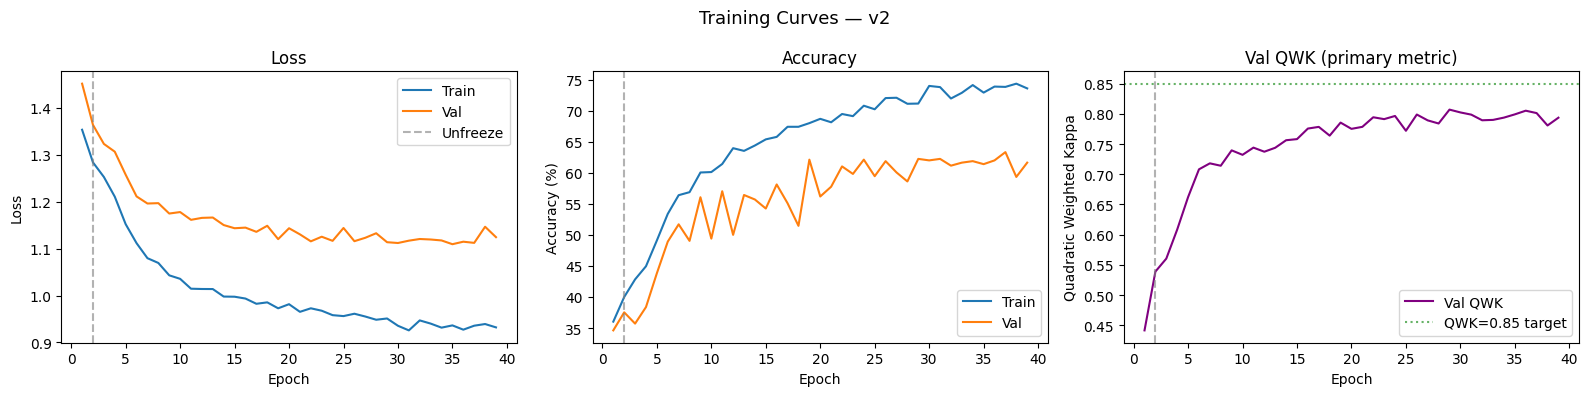

In [13]:
def merge_histories(*histories):
    merged = {k: [] for k in histories[0]}
    for h in histories:
        for k in merged:
            merged[k].extend(h[k])
    return merged

history    = merge_histories(history_phase1, history_phase2)
phase1_len = len(history_phase1['train_loss'])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Val')
axes[0].axvline(phase1_len, color='gray', linestyle='--', alpha=0.6, label='Unfreeze')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(epochs, [a*100 for a in history['train_acc']], label='Train')
axes[1].plot(epochs, [a*100 for a in history['val_acc']],   label='Val')
axes[1].axvline(phase1_len, color='gray', linestyle='--', alpha=0.6)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].set_title('Accuracy')
axes[1].legend()

axes[2].plot(epochs, history['val_qwk'], color='purple', label='Val QWK')
axes[2].axvline(phase1_len, color='gray', linestyle='--', alpha=0.6)
axes[2].axhline(0.85, color='green', linestyle=':', alpha=0.6, label='QWK=0.85 target')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Quadratic Weighted Kappa'); axes[2].set_title('Val QWK (primary metric)')
axes[2].legend()

plt.suptitle('Training Curves — v2', fontsize=13)
plt.tight_layout(); plt.show()

## 12. Bias–Variance Diagnostic

In [14]:
final_train = history['train_acc'][-1]
final_val   = history['val_acc'][-1]
gap         = final_train - final_val
loss_gap    = history['val_loss'][-1] - history['train_loss'][-1]
best_qwk    = max(history['val_qwk'])

print('=' * 60)
print('  BIAS–VARIANCE DIAGNOSTIC')
print('=' * 60)
print(f'  Final train accuracy : {final_train*100:.2f}%')
print(f'  Final val   accuracy : {final_val*100:.2f}%')
print(f'  Train–val gap        : {gap*100:+.2f} pp')
print(f'  Loss gap (val-train) : {loss_gap:+.4f}')
print(f'  Best val QWK         : {best_qwk:.4f}')
print('-' * 60)

if final_train < 0.65 and abs(gap) < 0.05:
    verdict = 'HIGH BIAS (underfitting)'
    fixes = ['Increase backbone LR', 'Reduce dropout further',
             'Longer phase-2 training', 'Try the larger backbone (set USE_SMALL_BACKBONE=False)']
elif gap > 0.10:
    verdict = 'HIGH VARIANCE (overfitting)'
    fixes = ['Increase augmentation strength', 'Raise dropout to 0.3/0.2',
             'Higher weight decay', 'Earlier early-stopping patience']
else:
    verdict = 'BALANCED'
    fixes = ['Try TTA in evaluation', 'Try the larger backbone',
             'Consider light MixUp (alpha=0.2)']

print(f'  Verdict: {verdict}')
for f in fixes:
    print(f'    → {f}')
print('=' * 60)

  BIAS–VARIANCE DIAGNOSTIC
  Final train accuracy : 73.57%
  Final val   accuracy : 61.62%
  Train–val gap        : +11.95 pp
  Loss gap (val-train) : +0.1923
  Best val QWK         : 0.8071
------------------------------------------------------------
  Verdict: HIGH VARIANCE (overfitting)
    → Increase augmentation strength
    → Raise dropout to 0.3/0.2
    → Higher weight decay
    → Earlier early-stopping patience


## 13. Test Set Evaluation — Plain & with TTA

We compute three numbers:
1. **Plain test accuracy & QWK** — direct apples-to-apples with v1's 65.46%
2. **TTA test accuracy & QWK** — 5 augmented views per image, softmax averaged. Typically +1–3 pp.
3. **Per-class precision/recall/F1** — to verify Grade 1 has improved.

In [15]:
# --- Plain evaluation ---
model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        logits = model(images)
        probs  = F.softmax(logits, dim=1)
        preds  = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.append(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.concatenate(all_probs, axis=0)

test_acc_plain = (all_preds == all_labels).mean()
test_qwk_plain = quadratic_weighted_kappa(all_labels, all_preds)
print(f'PLAIN  | Test Acc: {test_acc_plain*100:.2f}%  |  Test QWK: {test_qwk_plain:.4f}')

PLAIN  | Test Acc: 66.06%  |  Test QWK: 0.8324


In [16]:
# --- Test-Time Augmentation ---
# 5 views per image: original + flip + 3 small rotations. Softmax averaged.
class RawImageFolder(Dataset):
    """Returns the raw PIL image (after CLAHE only) so we can apply different transforms per view."""
    def __init__(self, root):
        self.ds = datasets.ImageFolder(root)
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        path, label = self.ds.samples[i]
        img = Image.open(path).convert('RGB')
        img = clahe(img)
        return img, label

tta_views = [
    transforms.Compose([
        transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.RandomRotation((5, 5)),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.RandomRotation((-5, -5)),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]),
]

raw_test = RawImageFolder(TEST_DIR)
tta_preds, tta_labels = [], []
model.eval()
with torch.no_grad():
    for idx in range(len(raw_test)):
        img, label = raw_test[idx]
        avg_prob = None
        for view in tta_views:
            t = view(img).unsqueeze(0).to(DEVICE)
            p = F.softmax(model(t), dim=1).cpu().numpy()[0]
            avg_prob = p if avg_prob is None else avg_prob + p
        avg_prob /= len(tta_views)
        tta_preds.append(int(avg_prob.argmax()))
        tta_labels.append(label)
        if (idx + 1) % 200 == 0:
            print(f'  TTA progress: {idx+1}/{len(raw_test)}')

tta_preds  = np.array(tta_preds)
tta_labels = np.array(tta_labels)
test_acc_tta = (tta_preds == tta_labels).mean()
test_qwk_tta = quadratic_weighted_kappa(tta_labels, tta_preds)

print()
print(f'PLAIN | Acc {test_acc_plain*100:5.2f}%  |  QWK {test_qwk_plain:.4f}')
print(f'TTA   | Acc {test_acc_tta*100:5.2f}%  |  QWK {test_qwk_tta:.4f}')
print(f'Δ     | Acc {(test_acc_tta-test_acc_plain)*100:+.2f} pp  |  QWK {test_qwk_tta-test_qwk_plain:+.4f}')

  TTA progress: 200/1656
  TTA progress: 400/1656
  TTA progress: 600/1656
  TTA progress: 800/1656
  TTA progress: 1000/1656
  TTA progress: 1200/1656
  TTA progress: 1400/1656
  TTA progress: 1600/1656

PLAIN | Acc 66.06%  |  QWK 0.8324
TTA   | Acc 66.73%  |  QWK 0.8383
Δ     | Acc +0.66 pp  |  QWK +0.0058


## 14. Per-class Report & Confusion Matrix (TTA predictions)

                    precision    recall  f1-score   support

 Grade 0 (Healthy)      0.778     0.804     0.791       639
Grade 1 (Doubtful)      0.359     0.497     0.417       296
 Grade 2 (Minimal)      0.736     0.488     0.587       447
Grade 3 (Moderate)      0.788     0.798     0.793       223
  Grade 4 (Severe)      0.750     0.941     0.835        51

          accuracy                          0.667      1656
         macro avg      0.682     0.706     0.684      1656
      weighted avg      0.692     0.667     0.671      1656



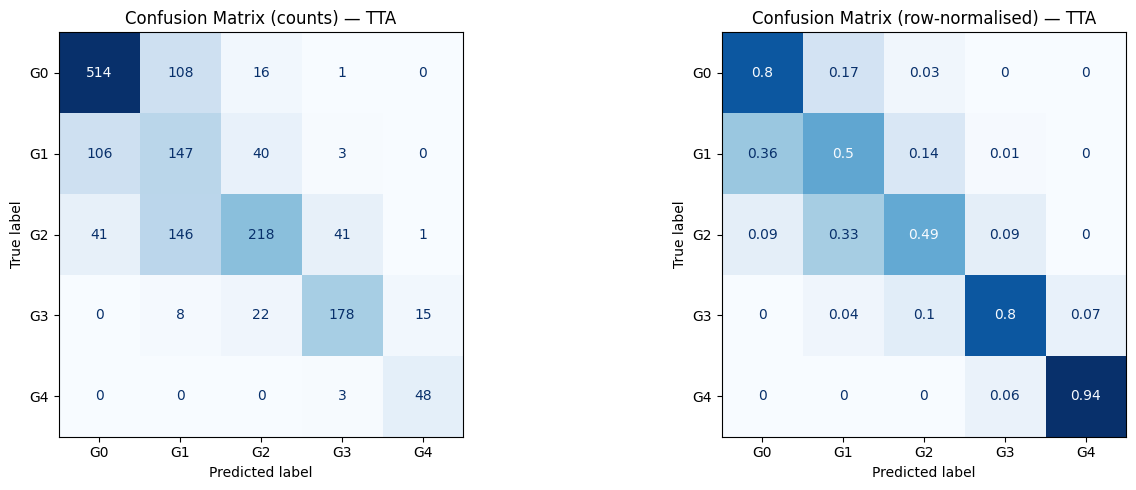

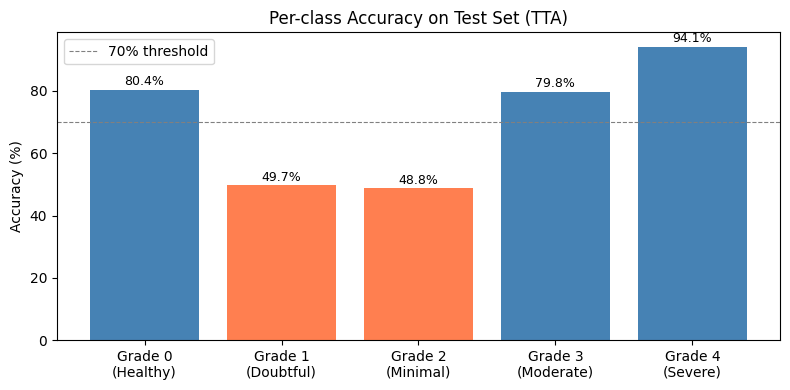

In [17]:
print(classification_report(
    tta_labels, tta_preds,
    target_names=[f'Grade {g} ({GRADE_LABELS[g]})' for g in range(NUM_CLASSES)],
    digits=3,
))

cm = confusion_matrix(tta_labels, tta_preds)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm, display_labels=[f'G{g}' for g in range(NUM_CLASSES)]
                      ).plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Confusion Matrix (counts) — TTA')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(np.round(cm_norm, 2),
                       display_labels=[f'G{g}' for g in range(NUM_CLASSES)]
                      ).plot(ax=ax2, colorbar=False, cmap='Blues')
ax2.set_title('Confusion Matrix (row-normalised) — TTA')

plt.tight_layout(); plt.show()

# Per-class accuracy bars
per_class_acc = cm.diagonal() / cm.sum(axis=1)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    [f'Grade {g}\n({GRADE_LABELS[g]})' for g in range(NUM_CLASSES)],
    per_class_acc * 100,
    color=['steelblue' if a >= 0.7 else 'coral' for a in per_class_acc],
)
ax.axhline(70, color='gray', linestyle='--', linewidth=0.8, label='70% threshold')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-class Accuracy on Test Set (TTA)')
ax.legend()
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

## 15. Comparison vs. v1 Baseline

In [18]:
baseline_v1 = {
    'test_accuracy': 0.6546,
    'grade_f1': {0: 0.78, 1: 0.27, 2: 0.60, 3: 0.79, 4: 0.83},
    'macro_f1':  0.65,
}

from sklearn.metrics import f1_score
v2_per_class_f1 = f1_score(tta_labels, tta_preds, average=None,
                           labels=list(range(NUM_CLASSES)))
v2_macro_f1     = f1_score(tta_labels, tta_preds, average='macro')

print(f"{'Metric':<22} {'v1':>10} {'v2 (TTA)':>12} {'Δ':>10}")
print('-' * 58)
print(f"{'Test accuracy':<22} {baseline_v1['test_accuracy']*100:>9.2f}% "
      f"{test_acc_tta*100:>11.2f}% {(test_acc_tta-baseline_v1['test_accuracy'])*100:>+9.2f} pp")
print(f"{'Macro F1':<22} {baseline_v1['macro_f1']:>10.3f} "
      f"{v2_macro_f1:>12.3f} {v2_macro_f1-baseline_v1['macro_f1']:>+10.3f}")
print(f"{'Test QWK':<22} {'(N/A)':>10} {test_qwk_tta:>12.4f}")
print('-' * 58)
print('Per-class F1:')
for g in range(NUM_CLASSES):
    delta = v2_per_class_f1[g] - baseline_v1['grade_f1'][g]
    arrow = '↑' if delta > 0 else ('↓' if delta < -0.01 else '–')
    print(f"  Grade {g} ({GRADE_LABELS[g]:<8}) {baseline_v1['grade_f1'][g]:>9.2f} "
          f"{v2_per_class_f1[g]:>12.3f} {delta:>+9.3f}  {arrow}")

Metric                         v1     v2 (TTA)          Δ
----------------------------------------------------------
Test accuracy              65.46%       66.73%     +1.27 pp
Macro F1                    0.650        0.684     +0.034
Test QWK                    (N/A)       0.8383
----------------------------------------------------------
Per-class F1:
  Grade 0 (Healthy )      0.78        0.791    +0.011  ↑
  Grade 1 (Doubtful)      0.27        0.417    +0.147  ↑
  Grade 2 (Minimal )      0.60        0.587    -0.013  ↓
  Grade 3 (Moderate)      0.79        0.793    +0.003  ↑
  Grade 4 (Severe  )      0.83        0.835    +0.005  ↑


## 16. Save Final Checkpoint

In [19]:
checkpoint = {
    'model_state_dict': model.state_dict(),
    'class_names': CLASS_NAMES,
    'num_classes': NUM_CLASSES,
    'img_size': IMG_SIZE,
    'architecture': BACKBONE,
    'test_accuracy_plain': float(test_acc_plain),
    'test_accuracy_tta':   float(test_acc_tta),
    'test_qwk_plain':      float(test_qwk_plain),
    'test_qwk_tta':        float(test_qwk_tta),
    'per_class_f1':        v2_per_class_f1.tolist(),
    'history':             history,
    'phase1_len':          phase1_len,
    'config': {
        'gaussian_sigma': GAUSSIAN_SIGMA,
        'head_lr': HEAD_LR,
        'backbone_lr': BACKBONE_LR,
        'weight_decay': WEIGHT_DECAY,
        'batch_size': BATCH_SIZE,
        'img_size': IMG_SIZE,
    },
}
save_path = MODEL_DIR / f'knee_kl_{BACKBONE}_v2_final.pth'
torch.save(checkpoint, save_path)
print(f'Saved: {save_path}')
print(f'  Plain Acc: {test_acc_plain*100:.2f}%   |  TTA Acc: {test_acc_tta*100:.2f}%')
print(f'  Plain QWK: {test_qwk_plain:.4f}     |  TTA QWK: {test_qwk_tta:.4f}')

Saved: /kaggle/working/models/knee_kl_efficientnet_b4_v2_final.pth
  Plain Acc: 66.06%   |  TTA Acc: 66.73%
  Plain QWK: 0.8324     |  TTA QWK: 0.8383


## 17. Single-Image Inference with TTA

Image     : 9713986L.png
True grade: 1 (Doubtful)
Predicted : 0 (Healthy)  conf 32.56%
Probabilities:
  Grade 0: █████████████ 32.56%
  Grade 1: ███████████ 29.04%
  Grade 2: █████████ 24.49%
  Grade 3: ████ 12.09%
  Grade 4:  1.82%


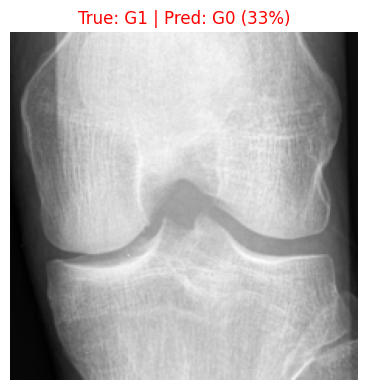

In [20]:
def predict_single_tta(image_path, model, n_views=5):
    img = Image.open(image_path).convert('RGB')
    img = clahe(img)
    model.eval()
    avg_prob = None
    with torch.no_grad():
        for view in tta_views[:n_views]:
            t = view(img).unsqueeze(0).to(DEVICE)
            p = F.softmax(model(t), dim=1).cpu().numpy()[0]
            avg_prob = p if avg_prob is None else avg_prob + p
        avg_prob /= n_views
    pred = int(avg_prob.argmax())
    return {
        'predicted_grade': pred,
        'label': GRADE_LABELS[pred],
        'confidence': float(avg_prob[pred]),
        'probabilities': {f'Grade {g}': float(p) for g, p in enumerate(avg_prob)},
    }


sample_paths = [p for p in TEST_DIR.rglob('*') if p.suffix.lower() in {'.png', '.jpg', '.jpeg'}]
sample = random.choice(sample_paths)
true_grade = int(sample.parent.name)

result = predict_single_tta(sample, model)
print(f'Image     : {sample.name}')
print(f'True grade: {true_grade} ({GRADE_LABELS[true_grade]})')
print(f'Predicted : {result["predicted_grade"]} ({result["label"]})  conf {result["confidence"]:.2%}')
print('Probabilities:')
for k, v in result['probabilities'].items():
    bar = '█' * int(v * 40)
    print(f'  {k}: {bar} {v:.2%}')

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(Image.open(sample), cmap='gray')
colour = 'green' if result['predicted_grade'] == true_grade else 'red'
ax.set_title(f'True: G{true_grade} | Pred: G{result["predicted_grade"]} ({result["confidence"]:.0%})', color=colour)
ax.axis('off'); plt.tight_layout(); plt.show()

## 18. Where to Go Next (if v2 still isn't enough)

If after this you want to push further, in expected-impact order:

1. **Joint cropping**. Train a tiny YOLOv8-nano on ~200 hand-labeled bounding boxes (or use a pre-existing knee-bbox dataset on Kaggle). Crop tightly to the joint before everything else. Often +5 pp on its own.
2. **RadImageNet pretraining**. Replace ImageNet weights with RadImageNet (X-ray-pretrained). Modest but consistent lift on radiograph tasks.
3. **Multi-architecture ensemble**. EfficientNet-B4 + ConvNeXt-Small + Swin-Tiny, average softmax. Usually +1–3 pp.
4. **5-fold stratified CV**. Refits 5 models — only worth doing once you've stabilized everything else.
5. **Self-supervised pretraining** (MAE/DINO) on OAI/MOST unlabeled X-rays before fine-tuning. The biggest possible lift but the most setup.

Run #1 first if you can — the rest are diminishing returns until joint cropping is in.